# MTX intraday — `MXFR1k.csv`

1-minute OHLC+Volume bars for MXF (= MTX 小型台指期) front-continuous,
2023-03-13 → 2026-05-22 (~3 years, ~900k bars). Both the day session
(08:45-13:45) and the night session (15:00-05:00) are included.

Goals of this notebook:
1. Load + sanity-check the file.
2. Tag each bar with its trading day and session (日盤 / 夜盤).
3. Cross-check: aggregate the day session and compare against
   `history_data/MTX_history.csv` daily OHLC to confirm the same instrument.
4. Map the intraday volume and volatility **profile** (where in the day
   does the action happen?).
5. 1-minute return distribution + auto-correlation → does intraday MTX
   mean-revert at 1-min horizon, or trend?
6. Eyeball a recent session for plausibility.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

mpl.rcParams["font.family"] = [
    "Hiragino Sans GB", "Heiti TC", "Songti SC",
    "PingFang HK", "Arial Unicode MS", "DejaVu Sans",
]

CSV_PATH   = Path("MXFR1k.csv")
DAILY_PATH = Path("history_data/MTX_history.csv")

print(f"intraday CSV : {CSV_PATH}  ({CSV_PATH.stat().st_size/1e6:.1f} MB)")
print(f"daily CSV    : {DAILY_PATH}")

intraday CSV : MXFR1k.csv  (58.9 MB)
daily CSV    : history_data/MTX_history.csv


## 1. Load + tag sessions

Parse the timestamp as the index, downcast numeric columns to save memory,
then tag each bar as:

- `session` ∈ {`day`, `night`} — based on time-of-day. TAIFEX rules:
  - day session: 08:45 ≤ time ≤ 13:45 (~300 minutes)
  - night session: 15:00 ≤ time < 05:00 next day (~840 minutes, crosses midnight)
- `trading_day` — the calendar date on which the trading day *begins*.
  For day-session bars and evening night-session bars (15:00-23:59) it's
  the same as the calendar date. For overnight bars (00:00-05:00) it's
  the **previous** calendar date (because that's when the trading day started).

In [2]:
df = pd.read_csv(
    CSV_PATH,
    parse_dates=["ts"],
    dtype={"Open": "float32", "High": "float32", "Low": "float32",
           "Close": "float32", "Volume": "int32", "Amount": "float64"},
)
df = df.set_index("ts").sort_index()
df.columns = df.columns.str.lower()      # open, high, low, close, volume, amount

# Session tagging
hr   = df.index.hour
mn   = df.index.minute
tod  = hr * 60 + mn                       # minute of day
is_day   = (tod >= 8 * 60 + 45) & (tod <= 13 * 60 + 45)
is_night = (tod >= 15 * 60) | (tod < 5 * 60 + 5)

df["session"] = np.where(is_day, "day",
                  np.where(is_night, "night", "outside"))

# Trading-day: previous calendar date for overnight (00:00-05:00) bars,
# otherwise the calendar date itself.
overnight = tod < 5 * 60 + 5
df["trading_day"] = (df.index.normalize() -
                     pd.to_timedelta(overnight.astype(int), unit="D")).date

print(f"Rows loaded   : {len(df):,}")
print(f"Time span     : {df.index[0]}  →  {df.index[-1]}")
print(f"Memory in RAM : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
print("Bar counts by session:")
print(df["session"].value_counts().to_string())
print()
print(f"Unique trading days: {df['trading_day'].nunique():,}")
df.head(3)

Rows loaded   : 900,499
Time span     : 2023-03-13 08:46:00  →  2026-05-22 13:45:00
Memory in RAM : 79.7 MB

Bar counts by session:
session
night      663467
day        237029
outside         3

Unique trading days: 777


,open,high,low,close,volume,amount,session,trading_day
ts,,,,,,,,
2023-03-13 08:46:00,15457.0,15488.0,15446.0,15479.0,5537,85665110.0,day,2023-03-13
2023-03-13 08:47:00,15478.0,15497.0,15478.0,15496.0,1808,28002369.0,day,2023-03-13
2023-03-13 08:48:00,15496.0,15515.0,15494.0,15508.0,2216,34362398.0,day,2023-03-13


## 2. Coverage — bars per session, gaps

Expected bar count per session (TAIFEX):
- **Day**:  08:46 → 13:45  →  300 bars  (clocked at end-of-minute)
- **Night**: 15:01 → 05:00  →  840 bars

Days that fall short of these counts probably had a session interrupted
(holiday, system outage, early close).

In [3]:
cov = (df.groupby(["trading_day", "session"]).size()
         .unstack(fill_value=0)
         .reindex(columns=["day", "night"], fill_value=0)
         .sort_index())

print(f"Trading-day coverage  (expected: day 300, night 840 bars)")
print(f"  Days with day session    : {(cov['day']   > 0).sum():>4} "
      f"(median {int(cov['day'][cov['day']>0].median())} bars/day, "
      f"min {int(cov['day'][cov['day']>0].min())}, max {int(cov['day'].max())})")
print(f"  Days with night session  : {(cov['night'] > 0).sum():>4} "
      f"(median {int(cov['night'][cov['night']>0].median())} bars/day, "
      f"min {int(cov['night'][cov['night']>0].min())}, max {int(cov['night'].max())})")
print(f"  Days with BOTH sessions  : {((cov['day']>0) & (cov['night']>0)).sum():>4}")
print(f"  Day-only days            : {((cov['day']>0) & (cov['night']==0)).sum():>4}")
print(f"  Night-only days          : {((cov['day']==0) & (cov['night']>0)).sum():>4}")
print()
print("First 10 days with truncated day session (<290 bars):")
short = cov[(cov["day"] > 0) & (cov["day"] < 290)]
print(short.head(10).to_string())

Trading-day coverage  (expected: day 300, night 840 bars)
  Days with day session    :  776 (median 300 bars/day, min 7, max 600)
  Days with night session  :  774 (median 840 bars/day, min 600, max 1680)
  Days with BOTH sessions  :  773
  Day-only days            :    3
  Night-only days          :    1

First 10 days with truncated day session (<290 bars):
session      day  night
trading_day            
2024-01-10   289    840
2025-04-07   160    840
2025-04-10   153    840
2025-11-22     7      0
2025-12-06    41      0


## 3. Cross-check against the daily `MTX_history.csv`

Aggregate the day-session 1-min bars to daily OHLC and compare against the
existing daily file. They should match precisely (same instrument, same
session). Any systematic discrepancy means we're looking at a different
contract series (e.g., MXF continuous vs MTX-front-month with explicit
roll dates).

In [4]:
# Aggregate day-session to daily OHLC
day_bars = df[df["session"] == "day"]
daily_from_min = day_bars.groupby("trading_day").agg(
    open=("open", "first"),
    high=("high", "max"),
    low =("low",  "min"),
    close=("close", "last"),
    volume=("volume", "sum"),
)
daily_from_min.index = pd.to_datetime(daily_from_min.index)

# Load the daily file (front-month, day session 一般)
import cta
asset = cta.load_asset("mtx", "1d", contract="front")
daily_file = asset[["open", "high", "low", "close", "volume"]]

# Inner-join on dates
join = daily_from_min.join(daily_file, lsuffix="_min", rsuffix="_file",
                            how="inner")
print(f"Overlap days: {len(join):,}  "
      f"({join.index[0].date()} → {join.index[-1].date()})")
print()
# Diff stats
for col in ["open", "high", "low", "close"]:
    d = join[f"{col}_min"] - join[f"{col}_file"]
    print(f"  {col:<6}: median diff {d.median():+.3f}  mean {d.mean():+.3f}  "
          f"max |diff| {d.abs().max():.3f}  match-rate {(d.abs() < 0.5).mean()*100:.1f}%")

# Volume comparison — note daily file's volume includes 盤後, intraday only day session
vol_ratio = (daily_from_min["volume"] / daily_file["volume"]).dropna()
print(f"\n  volume ratio (intraday day / daily file): "
      f"median {vol_ratio.median():.3f}  mean {vol_ratio.mean():.3f}")

Overlap days: 769  (2023-03-13 → 2026-05-15)

  open  : median diff +0.000  mean +0.000  max |diff| 0.000  match-rate 100.0%
  high  : median diff +0.000  mean +0.326  max |diff| 127.000  match-rate 99.6%
  low   : median diff +0.000  mean -0.749  max |diff| 186.000  match-rate 99.3%
  close : median diff +0.000  mean +1.107  max |diff| 378.000  match-rate 94.5%

  volume ratio (intraday day / daily file): median 0.997  mean 1.020


## 4. Intraday profile — volume and volatility by time-of-day

Average volume and absolute 1-minute return at each minute of day, split by
session. Classic intraday patterns to look for:

- **Volume U-shape** within a session — busy at open, quiet midday, busy at
  close.
- **Volatility U-shape** — same shape, since vol scales with order flow.
- **Reaction spikes** at exact times when scheduled overnight/US data lands
  (e.g. 21:30 TW = 09:30 EST = US cash open).

Aligning bars by minute-of-day lets us see all three at once.

/var/folders/ph/6k474nt57bsbh53k8tc674dr0000gn/T/ipykernel_19154/3983855046.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


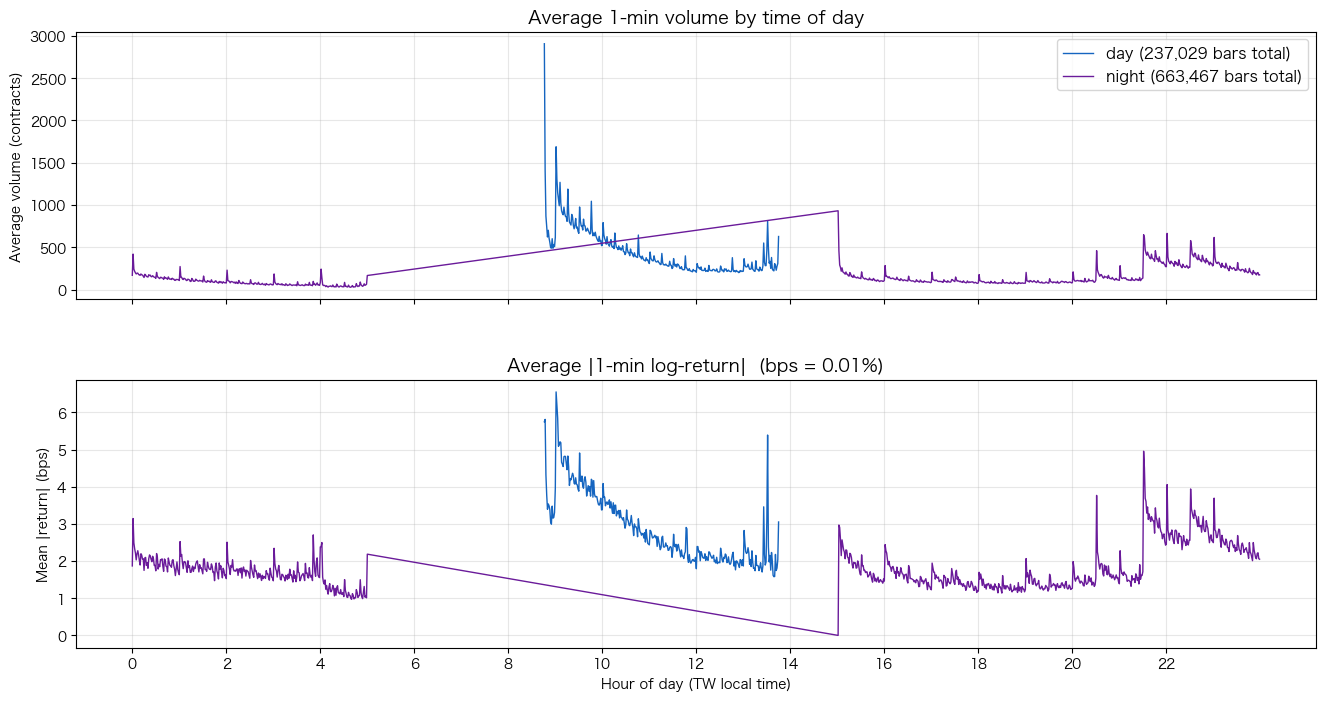

In [5]:
# Build a 1-minute log-return series
log_close = np.log(df["close"].astype(float))
ret_1m    = log_close.diff()
df["ret"] = ret_1m

# Don't compute returns across session boundaries (open ≠ prev session's close)
session_break = df["session"] != df["session"].shift(1)
df.loc[session_break, "ret"] = np.nan

df["abs_ret"] = df["ret"].abs()
df["tod_min"] = df.index.hour * 60 + df.index.minute

# Profile by minute-of-day per session
profile = (df.groupby(["session", "tod_min"])
             .agg(avg_volume=("volume", "mean"),
                  avg_abs_ret=("abs_ret", "mean"),
                  n=("close", "size")))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                         gridspec_kw={"hspace": 0.30})

for sess, color in [("day", "#1565c0"), ("night", "#6a1b9a")]:
    p = profile.loc[sess].sort_index()
    axes[0].plot(p.index / 60, p["avg_volume"], color=color, linewidth=1.0,
                 label=f"{sess} ({int(p['n'].sum()):,} bars total)")
    axes[1].plot(p.index / 60, p["avg_abs_ret"] * 1e4, color=color, linewidth=1.0)

axes[0].set_title("Average 1-min volume by time of day", fontsize=13)
axes[0].set_ylabel("Average volume (contracts)")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Average |1-min log-return|  (bps = 0.01%)", fontsize=13)
axes[1].set_ylabel("Mean |return| (bps)")
axes[1].set_xlabel("Hour of day (TW local time)")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

## 5. 1-minute return distribution + auto-correlation

Two diagnostics that govern what kind of intraday signal can work:

1. **Distribution** — does it look roughly normal, or are there fat tails
   that point at jump risk? Compare day-session vs night-session: night
   sessions tend to be thinner and more jumpy.
2. **Auto-correlation function (ACF)** at lags 1-30 minutes:
   - Positive ACF at short lags → momentum (trend continuation)
   - Negative ACF at short lags → mean reversion (good for HFT-style market-
     making / reverting signals)
   - Roughly zero → efficient at this horizon, harder to extract edge

We also compute the **AR(1) coefficient** and its half-life (in minutes).

Day   session:  bars 236,255  mean +0.004 bps  std 4.73 bps  AR(1) -0.0621  half-life 10.8 bars
Night session:  bars 662,694  mean +0.008 bps  std 3.12 bps  AR(1) -0.0085  half-life 81.5 bars


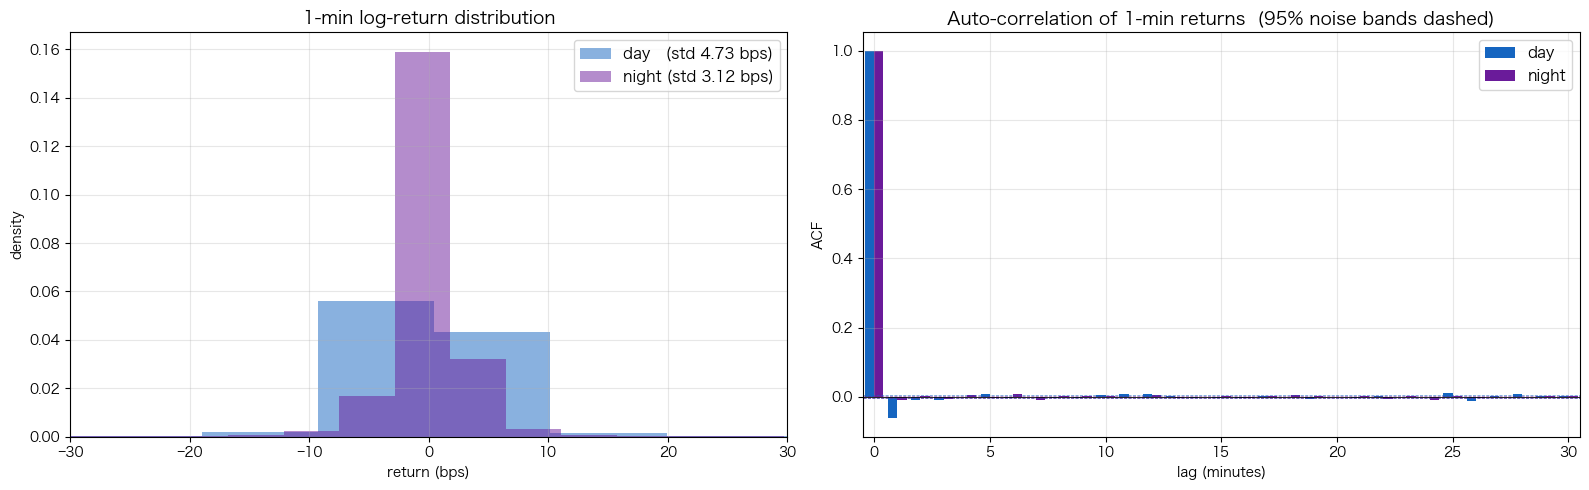

In [6]:
def ar1_coef(r: pd.Series) -> float:
    r = r.dropna()
    if len(r) < 100: return np.nan
    x, y = r.values[:-1], r.values[1:]
    x = x - x.mean(); y = y - y.mean()
    denom = (x ** 2).sum()
    return float((x * y).sum() / denom) if denom > 0 else np.nan

def acf_simple(r: pd.Series, max_lag: int = 30) -> pd.Series:
    r = r.dropna() - r.dropna().mean()
    var = (r ** 2).mean()
    return pd.Series([1.0] + [(r * r.shift(k)).mean() / var
                              for k in range(1, max_lag + 1)],
                     index=range(0, max_lag + 1))

ret_day   = df.loc[df["session"] == "day",   "ret"].dropna()
ret_night = df.loc[df["session"] == "night", "ret"].dropna()

acf_day   = acf_simple(ret_day,   max_lag=30)
acf_night = acf_simple(ret_night, max_lag=30)

ar1_d, ar1_n = ar1_coef(ret_day), ar1_coef(ret_night)
hl = lambda b: float("inf") if b >= 0 else -np.log(2) / np.log(1 + b)

print(f"Day   session:  bars {len(ret_day):>7,}  "
      f"mean {ret_day.mean()*1e4:+.3f} bps  std {ret_day.std()*1e4:.2f} bps  "
      f"AR(1) {ar1_d:+.4f}  half-life {hl(ar1_d):.1f} bars")
print(f"Night session:  bars {len(ret_night):>7,}  "
      f"mean {ret_night.mean()*1e4:+.3f} bps  std {ret_night.std()*1e4:.2f} bps  "
      f"AR(1) {ar1_n:+.4f}  half-life {hl(ar1_n):.1f} bars")

# Plot: distribution + ACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(ret_day.values   * 1e4, bins=120, alpha=0.5, color="#1565c0",
             label=f"day   (std {ret_day.std()*1e4:.2f} bps)",   density=True)
axes[0].hist(ret_night.values * 1e4, bins=120, alpha=0.5, color="#6a1b9a",
             label=f"night (std {ret_night.std()*1e4:.2f} bps)", density=True)
axes[0].set_title("1-min log-return distribution", fontsize=13)
axes[0].set_xlabel("return (bps)")
axes[0].set_ylabel("density")
axes[0].set_xlim(-30, 30)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0,  color="black", linewidth=0.6)
axes[1].bar(acf_day.index   - 0.2, acf_day.values,   width=0.4, color="#1565c0", label="day")
axes[1].bar(acf_night.index + 0.2, acf_night.values, width=0.4, color="#6a1b9a", label="night")
# 95% noise bands ~ ±1.96 / √N
band_d = 1.96 / np.sqrt(len(ret_day))
band_n = 1.96 / np.sqrt(len(ret_night))
axes[1].axhline(+band_d, color="#1565c0", linewidth=0.6, linestyle="--", alpha=0.6)
axes[1].axhline(-band_d, color="#1565c0", linewidth=0.6, linestyle="--", alpha=0.6)
axes[1].axhline(+band_n, color="#6a1b9a", linewidth=0.6, linestyle="--", alpha=0.6)
axes[1].axhline(-band_n, color="#6a1b9a", linewidth=0.6, linestyle="--", alpha=0.6)
axes[1].set_title("Auto-correlation of 1-min returns  (95% noise bands dashed)", fontsize=13)
axes[1].set_xlabel("lag (minutes)")
axes[1].set_ylabel("ACF")
axes[1].set_xlim(-0.5, 30.5)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Eyeball one recent trading day

Pick a date and plot all minute bars (day + night) end-to-end with volume
underneath. Useful sanity check that the timestamps line up correctly and
that the day-session-to-night-session transition (gap from 13:45 to 15:00)
appears as expected.

/var/folders/ph/6k474nt57bsbh53k8tc674dr0000gn/T/ipykernel_19154/1071845212.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


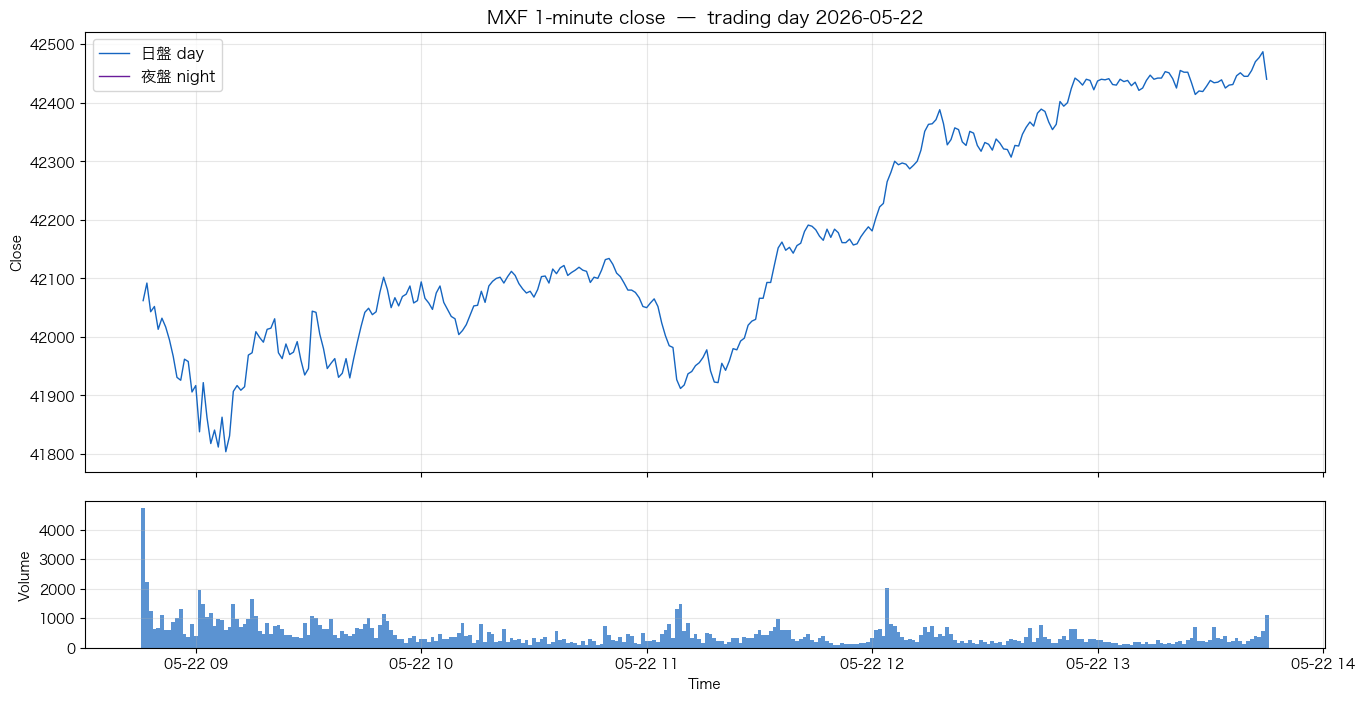

Trading day 2026-05-22:  300 bars   (300 day + 0 night)
  day  : open 42192   close 42440   high 42499   low 41791   vol 135,809


In [7]:
PICK_DAY = df["trading_day"].max()           # most recent trading day in the file
chunk = df[df["trading_day"] == PICK_DAY].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.10})

# Price line, colour-coded by session
day_mask   = chunk["session"] == "day"
night_mask = chunk["session"] == "night"
axes[0].plot(chunk.index[day_mask],   chunk["close"][day_mask].values,
             color="#1565c0", linewidth=1.0, label="日盤 day")
axes[0].plot(chunk.index[night_mask], chunk["close"][night_mask].values,
             color="#6a1b9a", linewidth=1.0, label="夜盤 night")
axes[0].set_title(f"MXF 1-minute close  —  trading day {PICK_DAY}", fontsize=13)
axes[0].set_ylabel("Close")
axes[0].legend(fontsize=11, loc="best")
axes[0].grid(True, alpha=0.3)

# Volume bars
axes[1].bar(chunk.index[day_mask],   chunk["volume"][day_mask].values,
            color="#1565c0", alpha=0.7, width=1/(24*60))
axes[1].bar(chunk.index[night_mask], chunk["volume"][night_mask].values,
            color="#6a1b9a", alpha=0.7, width=1/(24*60))
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Trading day {PICK_DAY}:  {len(chunk):,} bars   "
      f"({int((day_mask).sum())} day + {int((night_mask).sum())} night)")
print(f"  day  : open {chunk[day_mask]['open'].iloc[0]:.0f}   "
      f"close {chunk[day_mask]['close'].iloc[-1]:.0f}   "
      f"high {chunk[day_mask]['high'].max():.0f}   "
      f"low {chunk[day_mask]['low'].min():.0f}   "
      f"vol {int(chunk[day_mask]['volume'].sum()):,}")
if night_mask.any():
    print(f"  night: open {chunk[night_mask]['open'].iloc[0]:.0f}   "
          f"close {chunk[night_mask]['close'].iloc[-1]:.0f}   "
          f"high {chunk[night_mask]['high'].max():.0f}   "
          f"low {chunk[night_mask]['low'].min():.0f}   "
          f"vol {int(chunk[night_mask]['volume'].sum()):,}")